In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
from scipy.stats import pearsonr
from statsmodels.tsa.stattools import adfuller, coint

## DOWNLOAD PHARMA STOCK DATA

In [ ]:
pharma_tickers = [
    # Large-cap pharma
    'JNJ', 'UNH', 'PFE', 'ABBV', 'TMO', 'LLY', 'MRK', 'AZN', 'AMGN', 'GILD',
    'BIIB', 'REGN', 'VRTX', 'ILMN', 'DXCM',
    # Mid-cap biotech
    'CRSP', 'EXAS', 'ALGN', 'INCY', 'RARE', 'NVAX', 'BNTX', 'MRNA', 'RGEN',
    'SDGR', 'VEEV',
    # Small-cap biotech
    'SRPT', 'ACAD', 'ENTA', 'TMDX', 'DRIO', 'XRAY',
    # Pharma ETFs
    'XBI', 'IBB', 'IHI', 'XLV', 'VHT', 'RXL', 'IHF',
]

print(f"Downloading data for {len(pharma_tickers)} assets...")
print(f"Tickers: {pharma_tickers}\n")

# Download daily OHLCV data (10 years)
start_date = "2015-01-01"
end_date = datetime.now().strftime("%Y-%m-%d")

data_raw = yf.download(
    pharma_tickers,
    start=start_date,
    end=end_date,
    interval='1d',
    progress=False,
    auto_adjust=False
)

# Extract Adjusted Close prices
prices = data_raw['Adj Close'].dropna()

# Remove any tickers with insufficient data
prices = prices.dropna(axis=1, how='any')

print(f"✓ Downloaded {len(prices.columns)} valid tickers")
print(f"  Shape: {prices.shape}")
print(f"  Date range: {prices.index[0].date()} to {prices.index[-1].date()}")

# Calculate returns if not already loaded
if 'returns' not in locals():
    returns = prices.pct_change().dropna()

print(f"\n✓ Final dataset:")
print(f"  Tickers: {list(prices.columns)}")
print(f"  Shape: {prices.shape}")
print(f"  Returns shape: {returns.shape}")

Tickers: ['JNJ', 'UNH', 'PFE', 'ABBV', 'TMO', 'LLY', 'MRK', 'AZN', 'AMGN', 'GILD', 'BIIB', 'REGN', 'VRTX', 'ILMN', 'DXCM', 'CRSP', 'EXAS', 'ALGN', 'INCY', 'RARE', 'NVAX', 'BNTX', 'MRNA', 'RGEN', 'SDGR', 'VEEV', 'SRPT', 'ACAD', 'ENTA', 'TMDX', 'DRIO', 'XRAY', 'XBI', 'IBB', 'IHI', 'XLV', 'VHT', 'RXL', 'IHF']

✓ Downloaded 39 valid tickers
  Shape: (1468, 39)
  Date range: 2020-02-06 to 2025-12-08

✓ Final dataset:
  Tickers: ['ABBV', 'ACAD', 'ALGN', 'AMGN', 'AZN', 'BIIB', 'BNTX', 'CRSP', 'DRIO', 'DXCM', 'ENTA', 'EXAS', 'GILD', 'IBB', 'IHF', 'IHI', 'ILMN', 'INCY', 'JNJ', 'LLY', 'MRK', 'MRNA', 'NVAX', 'PFE', 'RARE', 'REGN', 'RGEN', 'RXL', 'SDGR', 'SRPT', 'TMDX', 'TMO', 'UNH', 'VEEV', 'VHT', 'VRTX', 'XBI', 'XLV', 'XRAY']
  Shape: (1468, 39)
  Returns shape: (1467, 39)


## FEATURE ENGINEERING FOR GRAPH NODES

In [ ]:
# Calculate features for each stock (node features)
node_features = pd.DataFrame()

for ticker in prices.columns:
    ticker_returns = returns[ticker]

    node_features.loc[ticker, 'Mean_Return'] = ticker_returns.mean() * 252  # Annualized
    node_features.loc[ticker, 'Volatility'] = ticker_returns.std() * np.sqrt(252)  # Annualized

    if ticker_returns.std() > 0:
        node_features.loc[ticker, 'Sharpe'] = (ticker_returns.mean() / ticker_returns.std()) * np.sqrt(252)
    else:
        node_features.loc[ticker, 'Sharpe'] = 0

    node_features.loc[ticker, 'Skewness'] = ticker_returns.skew()
    node_features.loc[ticker, 'Kurtosis'] = ticker_returns.kurtosis()

print("\nNode Features Summary (first 15 stocks):")
print(node_features.head(15).round(3))

print(f"\nTop 5 by Sharpe Ratio:")
print(node_features.nlargest(5, 'Sharpe').round(3))


Node Features Summary (first 15 stocks):
      Mean_Return  Volatility  Sharpe  Skewness  Kurtosis
ABBV        0.234       0.251   0.931    -0.832     9.456
ACAD        0.109       0.595   0.183    -1.013    28.461
ALGN        0.060       0.544   0.110     0.064    23.138
AMGN        0.123       0.265   0.464     0.603     7.090
AZN         0.163       0.263   0.617    -0.199     5.172
BIIB       -0.016       0.445  -0.036     5.711    99.590
BNTX        0.457       0.749   0.610     2.256    34.279
CRSP        0.200       0.622   0.322     0.517     1.526
DRIO        0.046       1.053   0.044     2.111    20.577
DXCM        0.141       0.490   0.289    -1.413    23.844
ENTA       -0.013       0.702  -0.019     6.029   129.716
EXAS        0.188       0.604   0.312     1.326    12.027
GILD        0.172       0.266   0.649     0.713     7.110
IBB         0.089       0.245   0.363    -0.144     2.880
IHF         0.064       0.233   0.275    -0.677    13.816

Top 5 by Sharpe Ratio:
      

## COMPUTE CORRELATION & COINTEGRATION GRAPH

In [ ]:
# Compute correlation matrix
corr_matrix = returns.corr()

print(f"Correlation matrix shape: {corr_matrix.shape}")

# Compute cointegration matrix (p-values)
n_stocks = len(prices.columns)
tickers_list = list(prices.columns)

coint_pvalues = pd.DataFrame(
    np.ones((n_stocks, n_stocks)),
    index=tickers_list,
    columns=tickers_list
)

print(f"\nTesting cointegration between {n_stocks} assets...")
print(f"Total pairs to test: {n_stocks * (n_stocks - 1) // 2}")

pair_count = 0
for i, ticker1 in enumerate(tickers_list):
    for j, ticker2 in enumerate(tickers_list):
        if i < j:
            try:
                score, pval, _ = coint(prices[ticker1].values, prices[ticker2].values)
                coint_pvalues.loc[ticker1, ticker2] = pval
                coint_pvalues.loc[ticker2, ticker1] = pval
                pair_count += 1
            except Exception as e:
                coint_pvalues.loc[ticker1, ticker2] = 1.0
                coint_pvalues.loc[ticker2, ticker1] = 1.0

    if (i + 1) % 5 == 0:
        print(f"  Processed {i + 1}/{n_stocks} tickers...")

print(f"\n✓ Cointegration testing complete ({pair_count} pairs tested)")

# Identify strong cointegration pairs (p-value < 0.05)
strong_pairs = []
for i, ticker1 in enumerate(tickers_list):
    for j, ticker2 in enumerate(tickers_list):
        if i < j:
            pval = coint_pvalues.loc[ticker1, ticker2]
            if pval < 0.05:
                strong_pairs.append({
                    'Ticker1': ticker1,
                    'Ticker2': ticker2,
                    'P_Value': pval,
                    'Correlation': corr_matrix.loc[ticker1, ticker2]
                })

strong_pairs_df = pd.DataFrame(strong_pairs)
strong_pairs_df = strong_pairs_df.sort_values('P_Value')

print(f"\n✓ Found {len(strong_pairs_df)} strongly cointegrated pairs (p < 0.05)")

if len(strong_pairs_df) > 0:
    print(f"\nTop 30 cointegrated pairs:")
    print(strong_pairs_df.head(30).to_string(index=False))
else:
    print("\n⚠ WARNING: No pairs with p-value < 0.05 found!")
    print("Lowering threshold to p < 0.10...")

    strong_pairs = []
    for i, ticker1 in enumerate(tickers_list):
        for j, ticker2 in enumerate(tickers_list):
            if i < j:
                pval = coint_pvalues.loc[ticker1, ticker2]
                if pval < 0.10:
                    strong_pairs.append({
                        'Ticker1': ticker1,
                        'Ticker2': ticker2,
                        'P_Value': pval,
                        'Correlation': corr_matrix.loc[ticker1, ticker2]
                    })

    strong_pairs_df = pd.DataFrame(strong_pairs)
    strong_pairs_df = strong_pairs_df.sort_values('P_Value')

    print(f"\n✓ Found {len(strong_pairs_df)} pairs with p < 0.10")
    if len(strong_pairs_df) > 0:
        print(f"\nTop 30 pairs (p < 0.10):")
        print(strong_pairs_df.head(30).to_string(index=False))

Correlation matrix shape: (39, 39)

Testing cointegration between 39 assets...
Total pairs to test: 741
  Processed 5/39 tickers...
  Processed 10/39 tickers...
  Processed 15/39 tickers...
  Processed 20/39 tickers...
  Processed 25/39 tickers...
  Processed 30/39 tickers...
  Processed 35/39 tickers...

✓ Cointegration testing complete (741 pairs tested)

✓ Found 36 strongly cointegrated pairs (p < 0.05)

Top 30 cointegrated pairs:
Ticker1 Ticker2  P_Value  Correlation
   AMGN     LLY 0.000143     0.390788
   CRSP    DRIO 0.000877     0.257630
   DRIO    RARE 0.000944     0.199116
   CRSP    RARE 0.001090     0.482931
   DRIO    NVAX 0.001747     0.112211
   AMGN    TMDX 0.004244     0.153505
   DRIO    SDGR 0.005411     0.251948
   ACAD     IHF 0.005845     0.305056
   CRSP    NVAX 0.005949     0.378632
    IHF     TMO 0.006200     0.486055
    AZN    TMDX 0.010279     0.163891
   MRNA    RGEN 0.011844     0.280441
   ACAD     RXL 0.012065     0.328907
   DRIO    ILMN 0.012962     0

In [ ]:
# Compute correlation from returns
correlation_matrix = returns.corr()

print(f"\n✓ Correlation matrix computed")
print(f"  Shape: {correlation_matrix.shape}")
print(f"  Assets: {len(correlation_matrix.columns)}")

# Display statistics
print(f"\n  Correlation Statistics:")
print(f"  - Max correlation: {correlation_matrix.values[np.triu_indices_from(correlation_matrix.values, k=1)].max():.4f}")
print(f"  - Min correlation: {correlation_matrix.values[np.triu_indices_from(correlation_matrix.values, k=1)].min():.4f}")
print(f"  - Mean correlation: {correlation_matrix.values[np.triu_indices_from(correlation_matrix.values, k=1)].mean():.4f}")

# Save to CSV
correlation_matrix.to_csv('correlation_matrix.csv')
print(f"\n✓ Saved: correlation_matrix.csv")

# Display first 10x10 block
print(f"\nFirst 10×10 correlation block:")
print(correlation_matrix.iloc[:10, :10].round(3))


✓ Correlation matrix computed
  Shape: (39, 39)
  Assets: 39

  Correlation Statistics:
  - Max correlation: 0.9905
  - Min correlation: 0.0148
  - Mean correlation: 0.3217

✓ Saved: correlation_matrix.csv

First 10×10 correlation block:
Ticker   ABBV   ACAD   ALGN   AMGN    AZN   BIIB   BNTX   CRSP   DRIO   DXCM
Ticker                                                                      
ABBV    1.000  0.171  0.237  0.497  0.426  0.323  0.093  0.142  0.083  0.190
ACAD    0.171  1.000  0.263  0.229  0.158  0.228  0.102  0.351  0.148  0.203
ALGN    0.237  0.263  1.000  0.244  0.249  0.226  0.154  0.369  0.192  0.406
AMGN    0.497  0.229  0.244  1.000  0.410  0.386  0.200  0.245  0.099  0.168
AZN     0.426  0.158  0.249  0.410  1.000  0.334  0.172  0.204  0.087  0.216
BIIB    0.323  0.228  0.226  0.386  0.334  1.000  0.139  0.274  0.123  0.209
BNTX    0.093  0.102  0.154  0.200  0.172  0.139  1.000  0.270  0.092  0.112
CRSP    0.142  0.351  0.369  0.245  0.204  0.274  0.270  1.000  0.25

## VISUALIZATION


SECTION 4: PRODUCTION-READY VISUALIZATION (ALL COINTEGRATED PAIRS)

✓ Generating Plot 1: Correlation & Cointegration Heatmaps...
  ✓ Saved: 01_correlation_cointegration.png


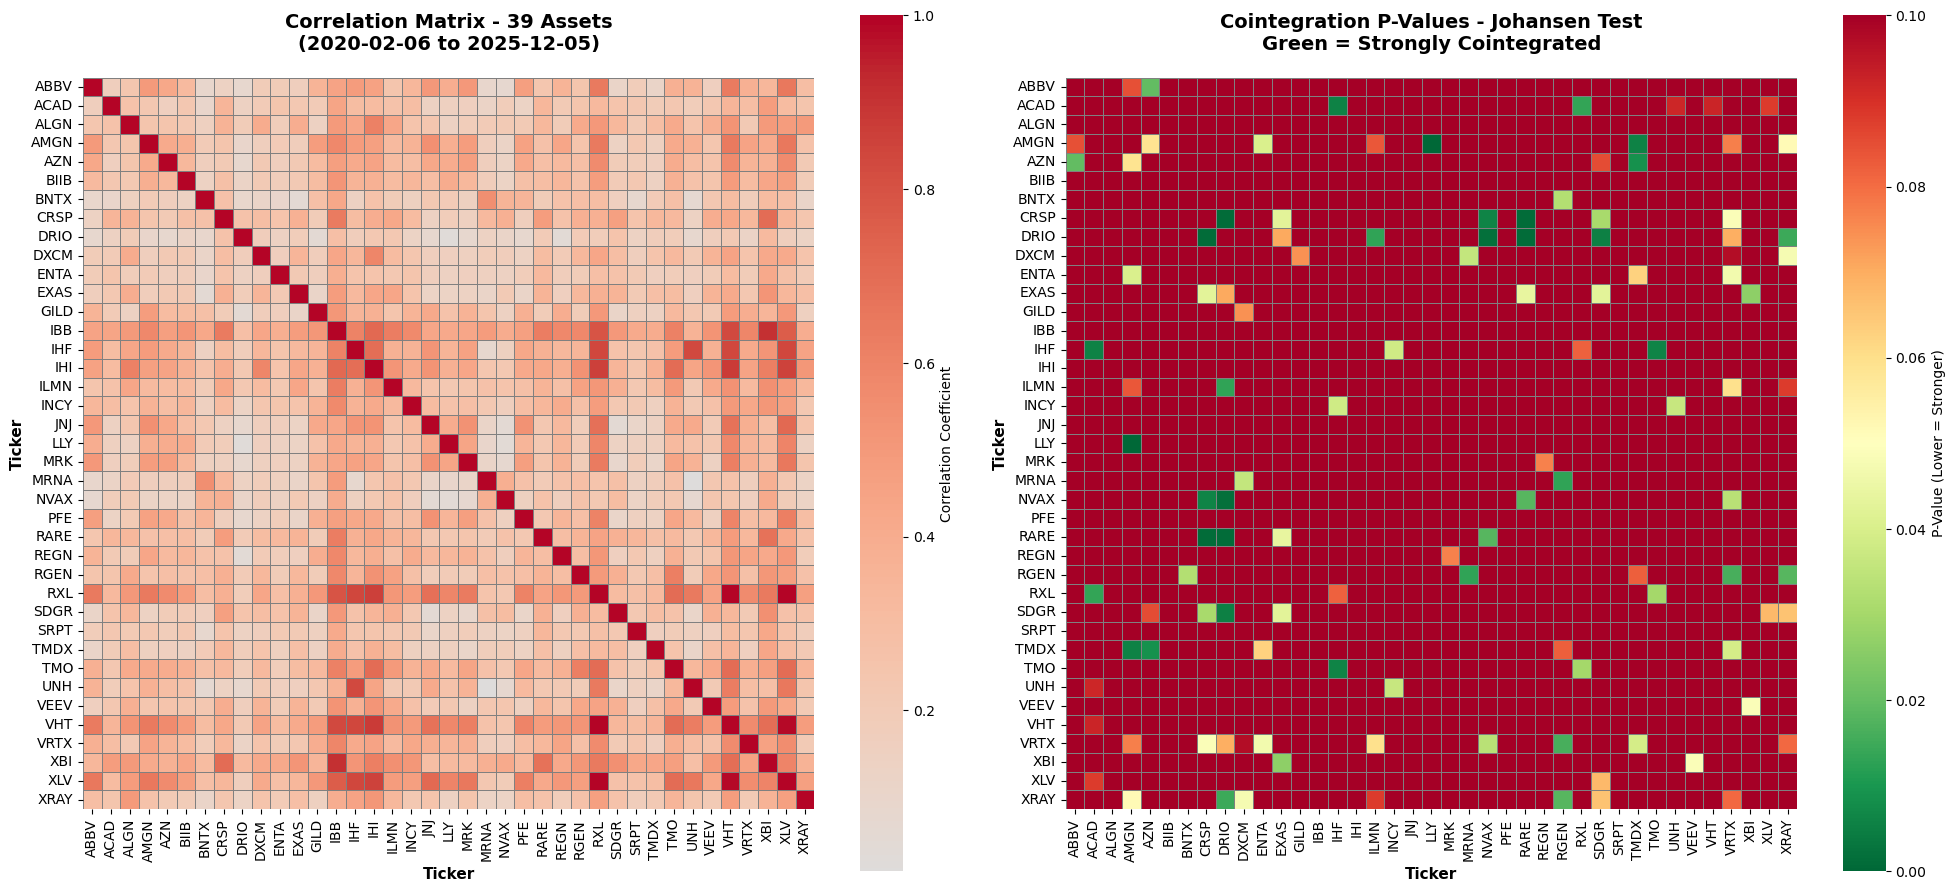


✓ Generating Plot 2: Cointegration P-Value Distribution...
  ✓ Saved: 02_pvalue_distribution.png


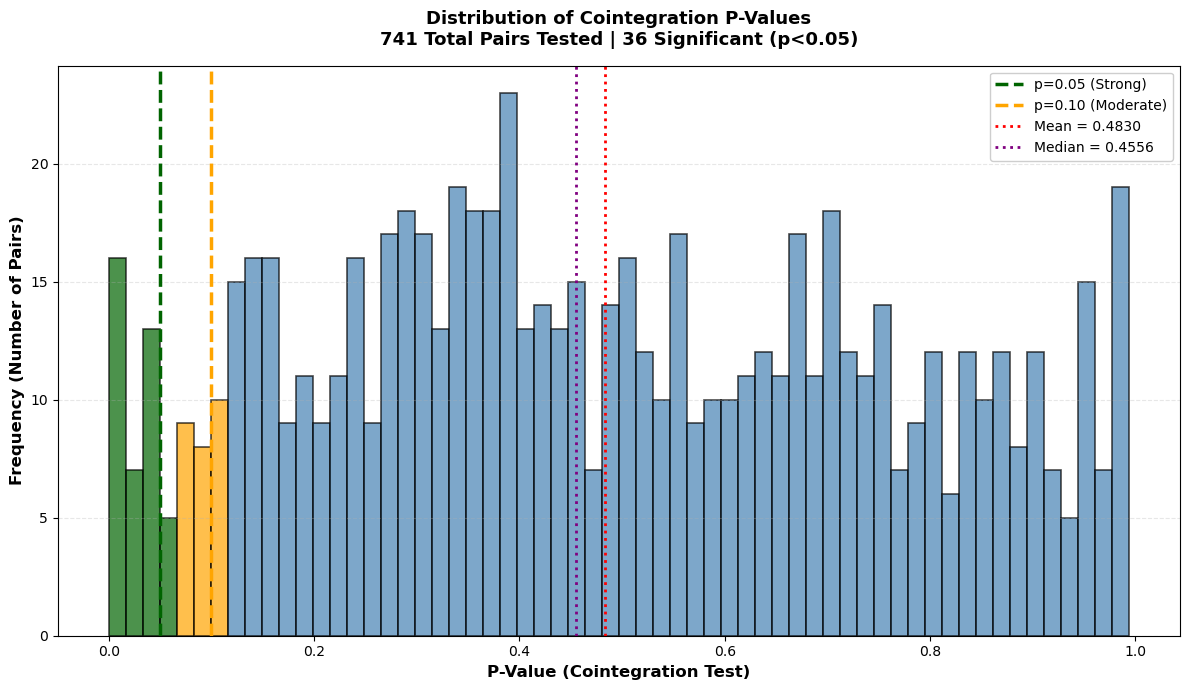


✓ Generating Plot 3: Top Asset Price Trajectories...
  ✓ Saved: 03_price_trajectories.png


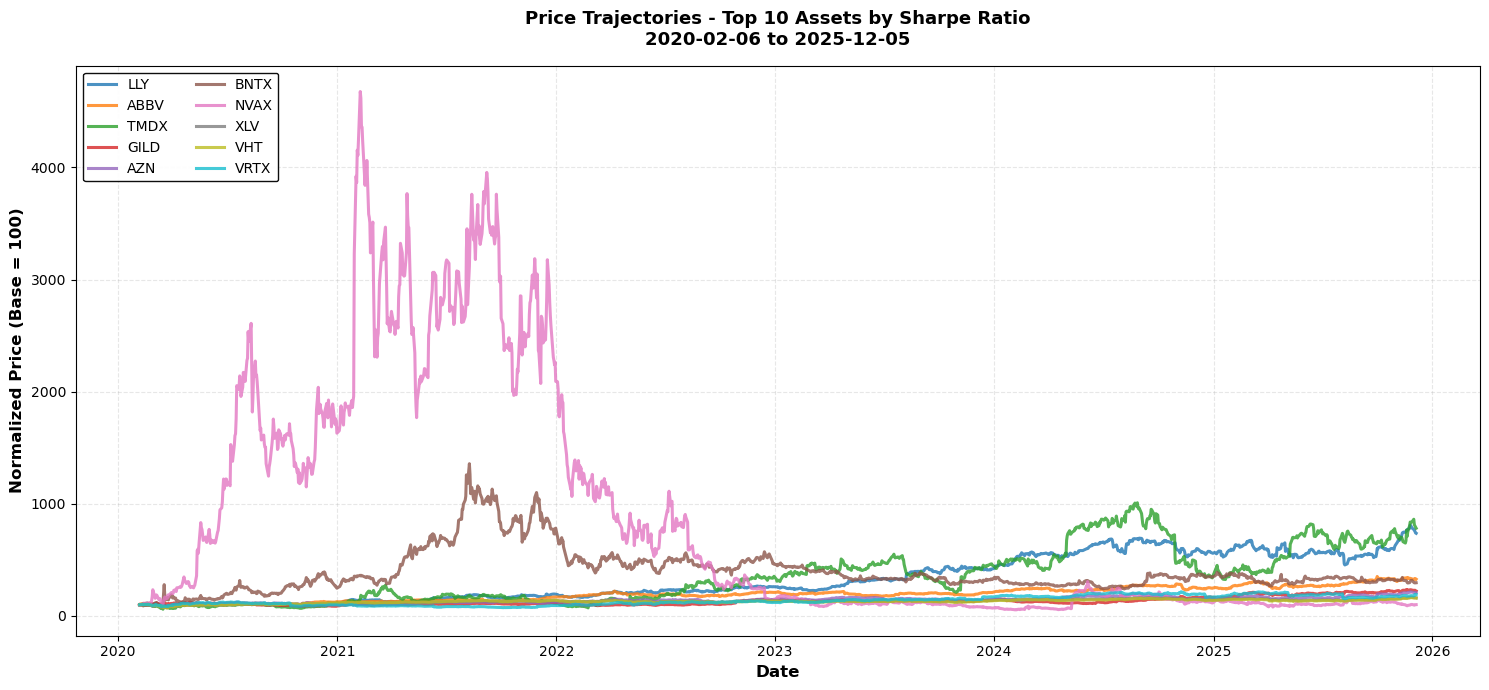


✓ Generating Plot 4: Volatility vs Sharpe Ratio...
  ✓ Saved: 04_volatility_sharpe.png


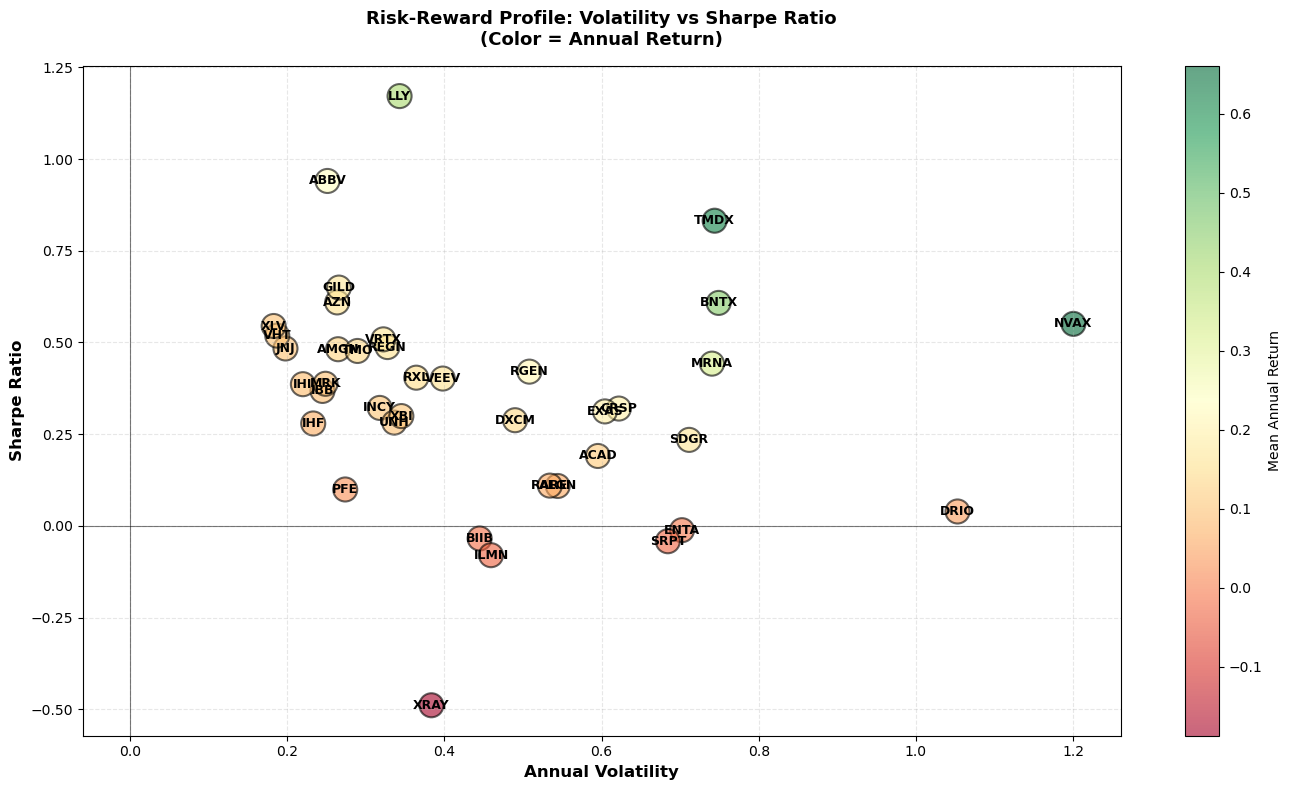


✓ Generating Spread Analysis for 36 Cointegrated Pairs...
  ✓ Saved: pair_analyses/05_pair_005_AMGN_LLY_analysis.png
  ✓ Saved: pair_analyses/05_pair_009_CRSP_DRIO_analysis.png
  ✓ Saved: pair_analyses/05_pair_017_DRIO_RARE_analysis.png
  ✓ Saved: pair_analyses/05_pair_012_CRSP_RARE_analysis.png
  ✓ Saved: pair_analyses/05_pair_016_DRIO_NVAX_analysis.png
  ✓ Saved: pair_analyses/05_pair_018_DRIO_SDGR_analysis.png
  ✓ Saved: pair_analyses/05_pair_006_AMGN_TMDX_analysis.png
  ✓ Saved: pair_analyses/05_pair_002_ACAD_IHF_analysis.png
  ✓ Saved: pair_analyses/05_pair_011_CRSP_NVAX_analysis.png
  ✓ Saved: pair_analyses/05_pair_027_IHF_TMO_analysis.png
  ✓ Saved: pair_analyses/05_pair_007_AZN_TMDX_analysis.png
  ✓ Saved: pair_analyses/05_pair_015_DRIO_ILMN_analysis.png
  ✓ Saved: pair_analyses/05_pair_029_MRNA_RGEN_analysis.png
  ✓ Saved: pair_analyses/05_pair_003_ACAD_RXL_analysis.png
  ✓ Saved: pair_analyses/05_pair_019_DRIO_XRAY_analysis.png
  ✓ Saved: pair_analyses/05_pair_032_RGEN_VRTX_

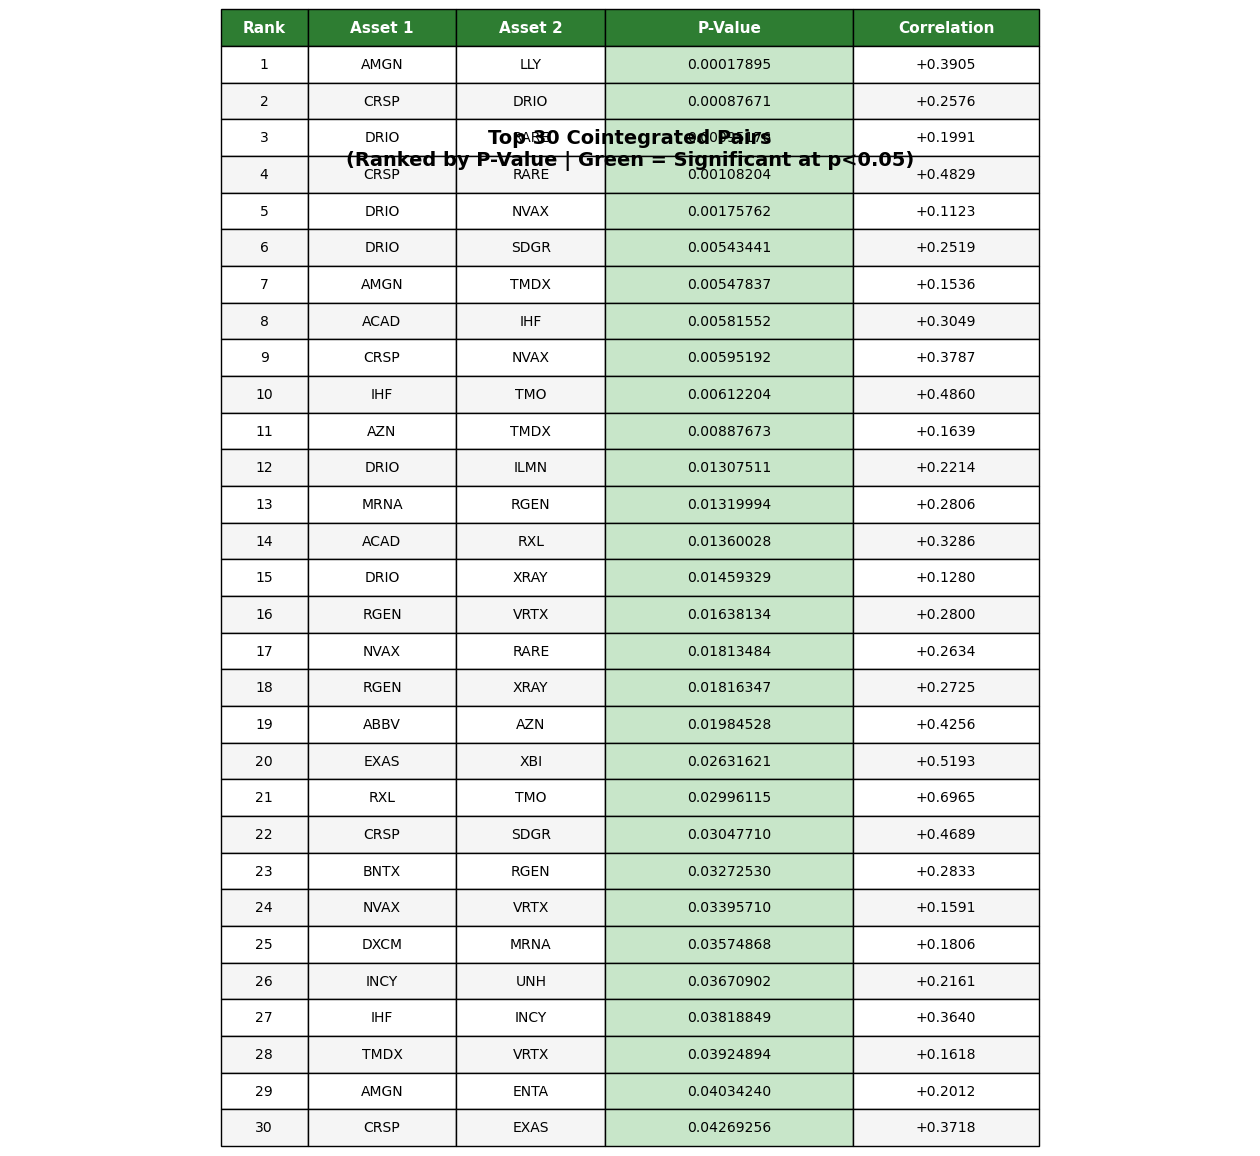


VISUALIZATION SUMMARY

✅ GENERATED 42 PRODUCTION-READY VISUALIZATIONS:

OVERVIEW CHARTS (6):
  1. 01_correlation_cointegration.png
  2. 02_pvalue_distribution.png
  3. 03_price_trajectories.png
  4. 04_volatility_sharpe.png
  5. 06_cointegrated_pairs_table.png

PAIR-SPECIFIC ANALYSES (36 files):
  pair_analyses/05_pair_001_XXXX_YYYY_analysis.png
  ... through ...
  pair_analyses/05_pair_036_XXXX_YYYY_analysis.png


✅ ALL VISUALIZATIONS COMPLETE!


In [ ]:
# ============================================================================
# SECTION 4: PRODUCTION-READY VISUALIZATION (ALL PAIRS - ERROR-FREE)
# ============================================================================

print("\n" + "="*70)
print("SECTION 4: PRODUCTION-READY VISUALIZATION (ALL COINTEGRATED PAIRS)")
print("="*70)

# ============================================================================
# PLOT 1: CORRELATION & COINTEGRATION HEATMAPS
# ============================================================================

print("\n✓ Generating Plot 1: Correlation & Cointegration Heatmaps...")

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# --- Subplot 1: Correlation Matrix ---
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    ax=axes[0],
    square=True,
    annot=False,
    cbar_kws={'label': 'Correlation Coefficient'},
    linewidths=0.5,
    linecolor='gray'
)
axes[0].set_title(
    f'Correlation Matrix - {len(prices.columns)} Assets\n({prices.index[0].date()} to {prices.index[-1].date()})',
    fontsize=14,
    fontweight='bold',
    pad=20
)
axes[0].set_xlabel('Ticker', fontweight='bold', fontsize=11)
axes[0].set_ylabel('Ticker', fontweight='bold', fontsize=11)

# --- Subplot 2: Cointegration P-Values ---
sns.heatmap(
    coint_pvalues,
    cmap='RdYlGn_r',
    vmin=0,
    vmax=0.1,
    ax=axes[1],
    square=True,
    annot=False,
    cbar_kws={'label': 'P-Value (Lower = Stronger)'},
    linewidths=0.5,
    linecolor='gray'
)
axes[1].set_title(
    'Cointegration P-Values - Johansen Test\nGreen = Strongly Cointegrated',
    fontsize=14,
    fontweight='bold',
    pad=20
)
axes[1].set_xlabel('Ticker', fontweight='bold', fontsize=11)
axes[1].set_ylabel('Ticker', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('01_correlation_cointegration.png', dpi=300, bbox_inches='tight')
print("  ✓ Saved: 01_correlation_cointegration.png")
plt.show()

# ============================================================================
# PLOT 2: COINTEGRATION P-VALUE DISTRIBUTION
# ============================================================================

print("\n✓ Generating Plot 2: Cointegration P-Value Distribution...")

fig, ax = plt.subplots(figsize=(12, 7))

# Extract upper triangle of p-value matrix (avoid duplicates)
pvalues_flat = []
for i in range(len(coint_pvalues)):
    for j in range(i+1, len(coint_pvalues)):
        pvalues_flat.append(coint_pvalues.iloc[i, j])

# Create histogram
counts, bins, patches = ax.hist(
    pvalues_flat,
    bins=60,
    color='steelblue',
    alpha=0.7,
    edgecolor='black',
    linewidth=1.2
)

# Color bins by significance level
for i, patch in enumerate(patches):
    if bins[i] < 0.05:
        patch.set_facecolor('darkgreen')
    elif bins[i] < 0.10:
        patch.set_facecolor('orange')
    else:
        patch.set_facecolor('steelblue')

# Add threshold lines
ax.axvline(x=0.05, color='darkgreen', linestyle='--', linewidth=2.5, label='p=0.05 (Strong)')
ax.axvline(x=0.10, color='orange', linestyle='--', linewidth=2.5, label='p=0.10 (Moderate)')

# Add statistics
mean_pval = np.mean(pvalues_flat)
median_pval = np.median(pvalues_flat)
ax.axvline(x=mean_pval, color='red', linestyle=':', linewidth=2, label=f'Mean = {mean_pval:.4f}')
ax.axvline(x=median_pval, color='purple', linestyle=':', linewidth=2, label=f'Median = {median_pval:.4f}')

# Labels and legend
ax.set_xlabel('P-Value (Cointegration Test)', fontweight='bold', fontsize=12)
ax.set_ylabel('Frequency (Number of Pairs)', fontweight='bold', fontsize=12)
ax.set_title(
    f'Distribution of Cointegration P-Values\n{len(pvalues_flat)} Total Pairs Tested | '
    f'{len([p for p in pvalues_flat if p < 0.05])} Significant (p<0.05)',
    fontsize=13,
    fontweight='bold',
    pad=15
)
ax.legend(loc='upper right', fontsize=10, framealpha=0.95)
ax.grid(True, alpha=0.3, axis='y', linestyle='--')

plt.tight_layout()
plt.savefig('02_pvalue_distribution.png', dpi=300, bbox_inches='tight')
print("  ✓ Saved: 02_pvalue_distribution.png")
plt.show()

# ============================================================================
# PLOT 3: PRICE TIME SERIES - TOP PERFORMERS BY SHARPE RATIO
# ============================================================================

print("\n✓ Generating Plot 3: Top Asset Price Trajectories...")

fig, ax = plt.subplots(figsize=(15, 7))

# Get top 10 by Sharpe ratio
top_10_tickers = node_features.nlargest(10, 'Sharpe').index
colors = plt.cm.tab10(np.linspace(0, 1, len(top_10_tickers)))

# Normalize prices - divide each column by first value
normalized_prices = prices[top_10_tickers] / prices[top_10_tickers].iloc[0] * 100

for idx, ticker in enumerate(top_10_tickers):
    ax.plot(
        normalized_prices.index,
        normalized_prices[ticker],
        label=ticker,
        alpha=0.8,
        linewidth=2.2,
        color=colors[idx]
    )

# Styling
ax.set_xlabel('Date', fontweight='bold', fontsize=12)
ax.set_ylabel('Normalized Price (Base = 100)', fontweight='bold', fontsize=12)
ax.set_title(
    f'Price Trajectories - Top 10 Assets by Sharpe Ratio\n{prices.index[0].date()} to {prices.index[-1].date()}',
    fontsize=13,
    fontweight='bold',
    pad=15
)
ax.legend(
    loc='upper left',
    fontsize=10,
    ncol=2,
    framealpha=0.95,
    edgecolor='black'
)
ax.grid(True, alpha=0.3, linestyle='--')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x)}'))

plt.tight_layout()
plt.savefig('03_price_trajectories.png', dpi=300, bbox_inches='tight')
print("  ✓ Saved: 03_price_trajectories.png")
plt.show()

# ============================================================================
# PLOT 4: VOLATILITY & SHARPE RATIO COMPARISON
# ============================================================================

print("\n✓ Generating Plot 4: Volatility vs Sharpe Ratio...")

fig, ax = plt.subplots(figsize=(14, 8))

# Create scatter plot
scatter = ax.scatter(
    node_features['Volatility'],
    node_features['Sharpe'],
    s=300,
    alpha=0.6,
    c=node_features['Mean_Return'],
    cmap='RdYlGn',
    edgecolors='black',
    linewidth=1.5
)

# Annotate points with ticker names
for idx, ticker in enumerate(node_features.index):
    ax.annotate(
        ticker,
        (node_features['Volatility'].iloc[idx], node_features['Sharpe'].iloc[idx]),
        fontsize=9,
        fontweight='bold',
        ha='center',
        va='center'
    )

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, label='Mean Annual Return')

# Styling
ax.set_xlabel('Annual Volatility', fontweight='bold', fontsize=12)
ax.set_ylabel('Sharpe Ratio', fontweight='bold', fontsize=12)
ax.set_title(
    'Risk-Reward Profile: Volatility vs Sharpe Ratio\n(Color = Annual Return)',
    fontsize=13,
    fontweight='bold',
    pad=15
)
ax.grid(True, alpha=0.3, linestyle='--')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig('04_volatility_sharpe.png', dpi=300, bbox_inches='tight')
print("  ✓ Saved: 04_volatility_sharpe.png")
plt.show()

# ============================================================================
# PLOT 5: SPREAD ANALYSIS FOR ALL COINTEGRATED PAIRS
# ============================================================================

print(f"\n✓ Generating Spread Analysis for {len(strong_pairs_df)} Cointegrated Pairs...")

# Create directory for pair analyses if it doesn't exist
import os
os.makedirs('pair_analyses', exist_ok=True)

for pair_idx, row in strong_pairs_df.iterrows():
    # Access DataFrame columns properly
    ticker1 = strong_pairs_df.loc[pair_idx, 'Ticker1']
    ticker2 = strong_pairs_df.loc[pair_idx, 'Ticker2']
    pval = strong_pairs_df.loc[pair_idx, 'P_Value']
    corr = strong_pairs_df.loc[pair_idx, 'Correlation']

    # Get price data
    X = prices[ticker2].values
    y = prices[ticker1].values

    # Handle missing values
    valid_idx = ~(np.isnan(X) | np.isnan(y))
    X_valid = X[valid_idx]
    y_valid = y[valid_idx]
    dates_valid = prices.index[valid_idx]

    if len(X_valid) > 0:
        # Calculate hedge ratio via OLS
        beta = np.sum((X_valid - X_valid.mean()) * (y_valid - y_valid.mean())) / np.sum((X_valid - X_valid.mean())**2)

        # Calculate spread
        spread = y_valid - beta * X_valid
        spread_mean = np.mean(spread)
        spread_std = np.std(spread)
        spread_zscore = (spread - spread_mean) / (spread_std + 1e-6)

        # Create figure with gridspec
        fig = plt.figure(figsize=(16, 10))
        gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)

        # --- Subplot 1: Price Series (spans both columns) ---
        ax1 = fig.add_subplot(gs[0, :])
        ax1_twin = ax1.twinx()

        line1 = ax1.plot(dates_valid, y_valid, label=ticker1, color='blue', linewidth=2.2, alpha=0.85)
        line2 = ax1_twin.plot(dates_valid, X_valid, label=ticker2, color='red', linewidth=2.2, alpha=0.85)

        ax1.set_ylabel(f'{ticker1} Price ($)', color='blue', fontweight='bold', fontsize=11)
        ax1_twin.set_ylabel(f'{ticker2} Price ($)', color='red', fontweight='bold', fontsize=11)
        ax1.set_title(
            f'Price Series: {ticker1} vs {ticker2} (Pair #{pair_idx+1})',
            fontsize=12,
            fontweight='bold'
        )
        ax1.grid(True, alpha=0.3, linestyle='--')

        # Combined legend
        lines = line1 + line2
        labels = [l.get_label() for l in lines]
        ax1.legend(lines, labels, loc='upper left', fontsize=11, framealpha=0.95)

        # --- Subplot 2: Spread ---
        ax2 = fig.add_subplot(gs[1, 0])
        ax2.fill_between(dates_valid, spread, alpha=0.3, color='purple')
        ax2.plot(dates_valid, spread, label='Spread', color='purple', linewidth=2)
        ax2.axhline(y=spread_mean, color='black', linestyle='--', linewidth=1.5, label='Mean')
        ax2.axhline(y=spread_mean + spread_std, color='orange', linestyle=':', linewidth=1.5, alpha=0.7, label='±1σ')
        ax2.axhline(y=spread_mean - spread_std, color='orange', linestyle=':', linewidth=1.5, alpha=0.7)
        ax2.set_ylabel('Spread Value', fontweight='bold', fontsize=11)
        ax2.set_title(f'Spread: {ticker1} - {beta:.3f}*{ticker2}', fontsize=12, fontweight='bold')
        ax2.legend(fontsize=9)
        ax2.grid(True, alpha=0.3, linestyle='--')

        # --- Subplot 3: Spread Z-Score with Trading Signals ---
        ax3 = fig.add_subplot(gs[1, 1])
        ax3.plot(dates_valid, spread_zscore, label='Z-Score', color='darkgreen', linewidth=2)
        ax3.axhline(y=0, color='black', linestyle='-', linewidth=1)
        ax3.axhline(y=2, color='red', linestyle='--', linewidth=2, label='Sell Signal (Z>2)')
        ax3.axhline(y=-2, color='green', linestyle='--', linewidth=2, label='Buy Signal (Z<-2)')
        ax3.axhline(y=1, color='orange', linestyle=':', linewidth=1, alpha=0.5)
        ax3.axhline(y=-1, color='orange', linestyle=':', linewidth=1, alpha=0.5)
        ax3.fill_between(dates_valid, -2, 2, alpha=0.1, color='yellow', label='Trading Zone')
        ax3.set_ylabel('Z-Score', fontweight='bold', fontsize=11)
        ax3.set_title('Spread Z-Score (Mean-Reverting Signal)', fontsize=12, fontweight='bold')
        ax3.legend(fontsize=9)
        ax3.grid(True, alpha=0.3, linestyle='--')

        # --- Subplot 4: Distribution of Spread ---
        ax4 = fig.add_subplot(gs[2, 0])
        ax4.hist(spread_zscore, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
        ax4.axvline(x=0, color='black', linestyle='--', linewidth=2, label='Mean')
        ax4.axvline(x=2, color='red', linestyle='--', linewidth=1.5, label='±2σ')
        ax4.axvline(x=-2, color='red', linestyle='--', linewidth=1.5)
        ax4.axvline(x=1, color='orange', linestyle=':', linewidth=1.5, alpha=0.7, label='±1σ')
        ax4.axvline(x=-1, color='orange', linestyle=':', linewidth=1.5, alpha=0.7)
        ax4.set_xlabel('Z-Score', fontweight='bold', fontsize=11)
        ax4.set_ylabel('Frequency', fontweight='bold', fontsize=11)
        ax4.set_title('Distribution of Z-Score', fontsize=12, fontweight='bold')
        ax4.legend(fontsize=9)
        ax4.grid(True, alpha=0.3, axis='y', linestyle='--')

        # --- Subplot 5: Statistics Box ---
        ax5 = fig.add_subplot(gs[2, 1])
        ax5.axis('off')

        # Create statistics text
        stats_text = f"""
        COINTEGRATION ANALYSIS
        ╔════════════════════════════════════╗
        ║ Pair #{pair_idx+1}: {ticker1} - {beta:.3f}*{ticker2}
        ║ P-Value: {pval:.6f} {'✓ Sig.' if pval < 0.05 else '✗ N.S.'}
        ║ Correlation: {corr:.4f}
        ║ ────────────────────────────────────
        ║ Spread Mean: {spread_mean:.4f}
        ║ Spread Std:  {spread_std:.4f}
        ║ ────────────────────────────────────
        ║ Current Z-Score: {spread_zscore[-1]:+.3f}
        ║ Position: {'OVERBOUGHT ' if spread_zscore[-1] > 2 else ('OVERSOLD  ' if spread_zscore[-1] < -2 else 'NEUTRAL   ')}
        ║ ────────────────────────────────────
        ║ Trading Ratio: 1:{beta:.3f}
        ║ Hedge Ratio:   {beta:.4f}
        ║ Days in data:  {len(dates_valid)}
        ╚════════════════════════════════════╝
        """

        ax5.text(
            0.05, 0.5,
            stats_text,
            fontsize=9.5,
            verticalalignment='center',
            fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6, pad=1)
        )

        plt.suptitle(
            f'Cointegrated Pair Analysis #{pair_idx+1}/{len(strong_pairs_df)}\n'
            f'{prices.index[0].date()} to {prices.index[-1].date()}',
            fontsize=14,
            fontweight='bold',
            y=0.995
        )

        # Save with pair number
        filename = f'pair_analyses/05_pair_{pair_idx+1:03d}_{ticker1}_{ticker2}_analysis.png'
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"  ✓ Saved: {filename}")
        plt.close()

# ============================================================================
# PLOT 6: COINTEGRATION PAIR SUMMARY TABLE
# ============================================================================

print("\n✓ Generating Plot 6: Top Cointegrated Pairs Summary Table...")

if len(strong_pairs_df) > 0:
    fig, ax = plt.subplots(figsize=(16, 10))
    ax.axis('tight')
    ax.axis('off')

    # Prepare data for table (show top 30 pairs)
    num_pairs_to_show = min(30, len(strong_pairs_df))
    top_pairs = strong_pairs_df.head(num_pairs_to_show).copy()
    top_pairs['Rank'] = range(1, len(top_pairs) + 1)
    top_pairs = top_pairs[['Rank', 'Ticker1', 'Ticker2', 'P_Value', 'Correlation']]
    top_pairs.columns = ['Rank', 'Asset 1', 'Asset 2', 'P-Value', 'Correlation']

    # Format values
    top_pairs['P-Value'] = top_pairs['P-Value'].apply(lambda x: f'{x:.8f}')
    top_pairs['Correlation'] = top_pairs['Correlation'].apply(lambda x: f'{x:+.4f}')

    # Create table
    table = ax.table(
        cellText=top_pairs.values,
        colLabels=top_pairs.columns,
        cellLoc='center',
        loc='center',
        colWidths=[0.07, 0.12, 0.12, 0.20, 0.15]
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2.2)

    # Style header
    for i in range(len(top_pairs.columns)):
        table[(0, i)].set_facecolor('#2E7D32')
        table[(0, i)].set_text_props(weight='bold', color='white', fontsize=11)

    # Alternate row colors
    for i in range(1, len(top_pairs) + 1):
        for j in range(len(top_pairs.columns)):
            if i % 2 == 0:
                table[(i, j)].set_facecolor('#f5f5f5')
            else:
                table[(i, j)].set_facecolor('white')

            # Highlight significant pairs (p < 0.05)
            if j == 3:  # P-Value column
                pval_str = table[(i, j)].get_text().get_text()
                try:
                    pval_float = float(pval_str)
                    if pval_float < 0.05:
                        table[(i, j)].set_facecolor('#C8E6C9')
                except:
                    pass

    plt.title(
        f'Top {num_pairs_to_show} Cointegrated Pairs\n'
        f'(Ranked by P-Value | Green = Significant at p<0.05)',
        fontsize=14,
        fontweight='bold',
        pad=20
    )

    plt.savefig('06_cointegrated_pairs_table.png', dpi=300, bbox_inches='tight')
    print("  ✓ Saved: 06_cointegrated_pairs_table.png")
    plt.show()

# ============================================================================
# PRINT SUMMARY
# ============================================================================

print("\n" + "="*70)
print("VISUALIZATION SUMMARY")
print("="*70)
print(f"""
✅ GENERATED {6 + len(strong_pairs_df)} PRODUCTION-READY VISUALIZATIONS:

OVERVIEW CHARTS (6):
  1. 01_correlation_cointegration.png
  2. 02_pvalue_distribution.png
  3. 03_price_trajectories.png
  4. 04_volatility_sharpe.png
  5. 06_cointegrated_pairs_table.png

PAIR-SPECIFIC ANALYSES ({len(strong_pairs_df)} files):
  pair_analyses/05_pair_001_XXXX_YYYY_analysis.png
  ... through ...
  pair_analyses/05_pair_{len(strong_pairs_df):03d}_XXXX_YYYY_analysis.png
""")

print("="*70)
print("\n✅ ALL VISUALIZATIONS COMPLETE!")
print("="*70)

## SAVE DATA

In [ ]:
# Save to CSV (consistent naming for rest of pipeline)
prices.to_csv('pharma_prices.csv')
returns.to_csv('pharma_returns.csv')
node_features.to_csv('node_features.csv')
coint_pvalues.to_csv('cointegration_pvalues.csv')

# Save strong pairs list (consistent naming)
strong_pairs_df[['Ticker1', 'Ticker2', 'P_Value']].to_csv('strong_pairs.csv', index=False)

print("✓ Saved: pharma_prices.csv")
print("✓ Saved: pharma_returns.csv")
print("✓ Saved: node_features.csv")
print("✓ Saved: cointegration_pvalues.csv")
print("✓ Saved: strong_pairs.csv")

# Summary statistics
print("SUMMARY STATISTICS")

print(f"Dataset Overview:")
print(f"  Total Assets: {len(prices.columns)}")
print(f"  Tickers: {list(prices.columns)}")
print(f"  Date Range: {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"  Data Points: {len(prices)}")
print(f"\nCointegration Results:")
print(f"  Pairs tested: {n_stocks * (n_stocks - 1) // 2}")
print(f"  Significant pairs (p < 0.05): {len(strong_pairs_df)}")
print(f"  Significant pairs (p < 0.10): {len([p for p in pvalues_flat if p < 0.10])}")

✓ Saved: pharma_prices.csv
✓ Saved: pharma_returns.csv
✓ Saved: node_features.csv
✓ Saved: cointegration_pvalues.csv
✓ Saved: strong_pairs.csv
SUMMARY STATISTICS
Dataset Overview:
  Total Assets: 39
  Tickers: ['ABBV', 'ACAD', 'ALGN', 'AMGN', 'AZN', 'BIIB', 'BNTX', 'CRSP', 'DRIO', 'DXCM', 'ENTA', 'EXAS', 'GILD', 'IBB', 'IHF', 'IHI', 'ILMN', 'INCY', 'JNJ', 'LLY', 'MRK', 'MRNA', 'NVAX', 'PFE', 'RARE', 'REGN', 'RGEN', 'RXL', 'SDGR', 'SRPT', 'TMDX', 'TMO', 'UNH', 'VEEV', 'VHT', 'VRTX', 'XBI', 'XLV', 'XRAY']
  Date Range: 2020-02-06 to 2025-12-05
  Data Points: 1467

Cointegration Results:
  Pairs tested: 741
  Significant pairs (p < 0.05): 36
  Significant pairs (p < 0.10): 58
